### Reading & Importing data


In [2]:
library(ggthemes)
library(magrittr) 
library(rvest)
library(dplyr)
library(tidyverse)
library(tidyr)
library(ggplot2)
library(lubridate)
install.packages("geosphere")
library(geosphere)

#import data

data_02 <- read.csv("JC-201902-citibike-tripdata.csv", header = T, sep = ",")
data_03 <- read.csv("JC-201903-citibike-tripdata.csv", header = T, sep = ",")
data_04 <- read.csv("JC-201904-citibike-tripdata.csv", header = T, sep = ",")
data_05 <- read.csv("JC-201905-citibike-tripdata.csv", header = T, sep = ",")
data_06 <- read.csv("JC-201906-citibike-tripdata.csv", header = T, sep = ",")





I pacchetti binari scaricati sono in
	/var/folders/tg/0l3b46ln1f7_m6ctvksnpg6c0000gn/T//RtmpaIW6ba/downloaded_packages


### Creating a common tibble & remove missing values 

In [3]:
#create a common tibble 

data <- rbind(data_02, data_03, data_04, data_05, data_06 )
data <- as_tibble(data)
data


#Removing missing data 

data <- drop_na(data)
str(data)



tripduration,starttime,stoptime,start.station.id,start.station.name,start.station.latitude,start.station.longitude,end.station.id,end.station.name,end.station.latitude,end.station.longitude,bikeid,usertype,birth.year,gender
<int>,<chr>,<chr>,<int>,<chr>,<dbl>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<int>,<chr>,<int>,<int>
142,2019-02-01 15:35:02.0820,2019-02-01 15:37:24.1360,3183,Exchange Place,40.71625,-74.03346,3639,Harborside,40.71925,-74.03423,29677,Subscriber,1963,1
223,2019-02-01 17:00:46.8900,2019-02-01 17:04:30.5500,3183,Exchange Place,40.71625,-74.03346,3681,Grand St,40.71518,-74.03768,26234,Subscriber,1992,2
106,2019-02-01 17:08:01.3260,2019-02-01 17:09:47.4400,3183,Exchange Place,40.71625,-74.03346,3184,Paulus Hook,40.71415,-74.03355,29588,Subscriber,1960,1
370,2019-02-01 17:09:31.2100,2019-02-01 17:15:41.6550,3183,Exchange Place,40.71625,-74.03346,3211,Newark Ave,40.72153,-74.04630,29250,Subscriber,1976,1
315,2019-02-01 17:19:53.2490,2019-02-01 17:25:09.1400,3183,Exchange Place,40.71625,-74.03346,3273,Manila & 1st,40.72165,-74.04288,29586,Subscriber,1980,1
145,2019-02-01 17:32:53.2630,2019-02-01 17:35:18.7510,3183,Exchange Place,40.71625,-74.03346,3214,Essex Light Rail,40.71277,-74.03649,26153,Subscriber,1984,1
1625,2019-02-01 17:39:55.5390,2019-02-01 18:07:01.2660,3183,Exchange Place,40.71625,-74.03346,3186,Grove St PATH,40.71959,-74.04312,29242,Subscriber,1993,1
485,2019-02-01 17:46:32.7540,2019-02-01 17:54:37.9890,3183,Exchange Place,40.71625,-74.03346,3186,Grove St PATH,40.71959,-74.04312,29496,Subscriber,1970,1
632,2019-02-01 18:05:26.8150,2019-02-01 18:15:59.1050,3183,Exchange Place,40.71625,-74.03346,3278,Monmouth and 6th,40.72569,-74.04879,26307,Customer,1981,1


tibble [150,792 x 15] (S3: tbl_df/tbl/data.frame)
 $ tripduration           : int [1:150792] 142 223 106 370 315 145 1625 485 632 235 ...
 $ starttime              : chr [1:150792] "2019-02-01 15:35:02.0820" "2019-02-01 17:00:46.8900" "2019-02-01 17:08:01.3260" "2019-02-01 17:09:31.2100" ...
 $ stoptime               : chr [1:150792] "2019-02-01 15:37:24.1360" "2019-02-01 17:04:30.5500" "2019-02-01 17:09:47.4400" "2019-02-01 17:15:41.6550" ...
 $ start.station.id       : int [1:150792] 3183 3183 3183 3183 3183 3183 3183 3183 3183 3183 ...
 $ start.station.name     : chr [1:150792] "Exchange Place" "Exchange Place" "Exchange Place" "Exchange Place" ...
 $ start.station.latitude : num [1:150792] 40.7 40.7 40.7 40.7 40.7 ...
 $ start.station.longitude: num [1:150792] -74 -74 -74 -74 -74 ...
 $ end.station.id         : int [1:150792] 3639 3681 3184 3211 3273 3214 3186 3186 3278 3681 ...
 $ end.station.name       : chr [1:150792] "Harborside" "Grand St" "Paulus Hook" "Newark Ave" ...
 $ end

### Evaluating the average and the median trip duration in minutes

In [4]:
head(data)

# Average trip duration in minutes 
avg_time <- mean(data$tripduration)/60
avg_time 

# Median trip duration in minutes 
mdn_time <- median(data$tripduration)/60
mdn_time

tripduration,starttime,stoptime,start.station.id,start.station.name,start.station.latitude,start.station.longitude,end.station.id,end.station.name,end.station.latitude,end.station.longitude,bikeid,usertype,birth.year,gender
<int>,<chr>,<chr>,<int>,<chr>,<dbl>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<int>,<chr>,<int>,<int>
142,2019-02-01 15:35:02.0820,2019-02-01 15:37:24.1360,3183,Exchange Place,40.71625,-74.03346,3639,Harborside,40.71925,-74.03423,29677,Subscriber,1963,1
223,2019-02-01 17:00:46.8900,2019-02-01 17:04:30.5500,3183,Exchange Place,40.71625,-74.03346,3681,Grand St,40.71518,-74.03768,26234,Subscriber,1992,2
106,2019-02-01 17:08:01.3260,2019-02-01 17:09:47.4400,3183,Exchange Place,40.71625,-74.03346,3184,Paulus Hook,40.71415,-74.03355,29588,Subscriber,1960,1
370,2019-02-01 17:09:31.2100,2019-02-01 17:15:41.6550,3183,Exchange Place,40.71625,-74.03346,3211,Newark Ave,40.72153,-74.04630,29250,Subscriber,1976,1
315,2019-02-01 17:19:53.2490,2019-02-01 17:25:09.1400,3183,Exchange Place,40.71625,-74.03346,3273,Manila & 1st,40.72165,-74.04288,29586,Subscriber,1980,1
145,2019-02-01 17:32:53.2630,2019-02-01 17:35:18.7510,3183,Exchange Place,40.71625,-74.03346,3214,Essex Light Rail,40.71277,-74.03649,26153,Subscriber,1984,1


[1] 12.81071

[1] 5.683333

### The minimum and maximum trip duration; does that seem like a plausible value?

In [5]:
# Minimum trip duration in minutes 
min_time <- min(data$tripduration)/60
min_time

# Maximum trip duration in days 
max_time <- max(data$tripduration)/(60*24)
max_time #it does not seem like a plausabile value

[1] 1.016667

[1] 1200.708

###  Repeatting the calculation of the average (and the median) trip duration by excluding trips longer than 3 hours. Next, evaluate the number of skimmed entries

In [6]:
# Average trip duration in minutes excluding trips > 3h 

trips_less_3h <- data %>% filter((data$tripduration)/(60*24) < 3) # created a tibble of trips with time duration less than 3h
avg_time_less_3h <- mean(trips_less_3h$tripduration)/60
avg_time_less_3h

# Median trip duration in minutes excluding trips > 3h 

mdn_time_less_3h <- median(trips_less_3h$tripduration)/60
mdn_time_less_3h

str(trips_less_3h) #Evaluating the number of skimmed entries , 241 rows 



[1] 8.505274

[1] 5.633333

tibble [149,241 x 15] (S3: tbl_df/tbl/data.frame)
 $ tripduration           : int [1:149241] 142 223 106 370 315 145 1625 485 632 235 ...
 $ starttime              : chr [1:149241] "2019-02-01 15:35:02.0820" "2019-02-01 17:00:46.8900" "2019-02-01 17:08:01.3260" "2019-02-01 17:09:31.2100" ...
 $ stoptime               : chr [1:149241] "2019-02-01 15:37:24.1360" "2019-02-01 17:04:30.5500" "2019-02-01 17:09:47.4400" "2019-02-01 17:15:41.6550" ...
 $ start.station.id       : int [1:149241] 3183 3183 3183 3183 3183 3183 3183 3183 3183 3183 ...
 $ start.station.name     : chr [1:149241] "Exchange Place" "Exchange Place" "Exchange Place" "Exchange Place" ...
 $ start.station.latitude : num [1:149241] 40.7 40.7 40.7 40.7 40.7 ...
 $ start.station.longitude: num [1:149241] -74 -74 -74 -74 -74 ...
 $ end.station.id         : int [1:149241] 3639 3681 3184 3211 3273 3214 3186 3186 3278 3681 ...
 $ end.station.name       : chr [1:149241] "Harborside" "Grand St" "Paulus Hook" "Newark Ave" ...
 $ end

### Plotting the distribution of trip duration after the skimming of the previous point

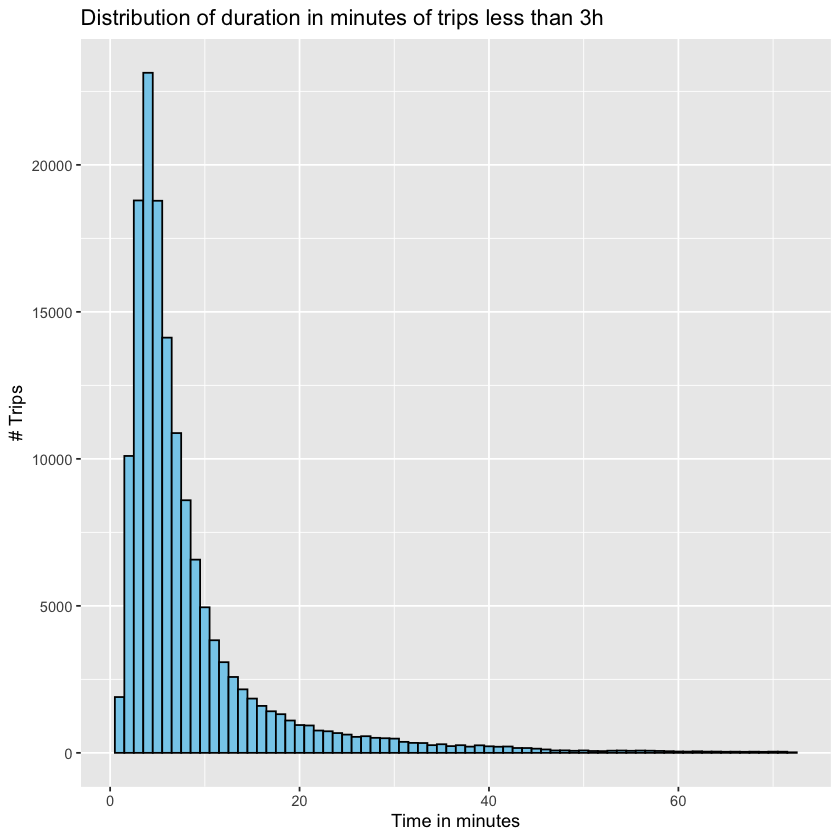

In [7]:
# Distribution of trip duration in minutes 
ggplot(trips_less_3h, aes(x = (tripduration)/60)) +
    geom_histogram(binwidth = 1, fill = "skyblue", color = "black") + 
    ggtitle("Distribution of duration in minutes of trips less than 3h") +
    xlab("Time in minutes") + 
    ylab("# Trips")


### Plotting the monthly average trip duration

# A tibble: 5 x 2
  month avg_time
  <dbl>    <dbl>
1     2     605.
2     3     546.
3     4     714.
4     5     824.
5     6     974.


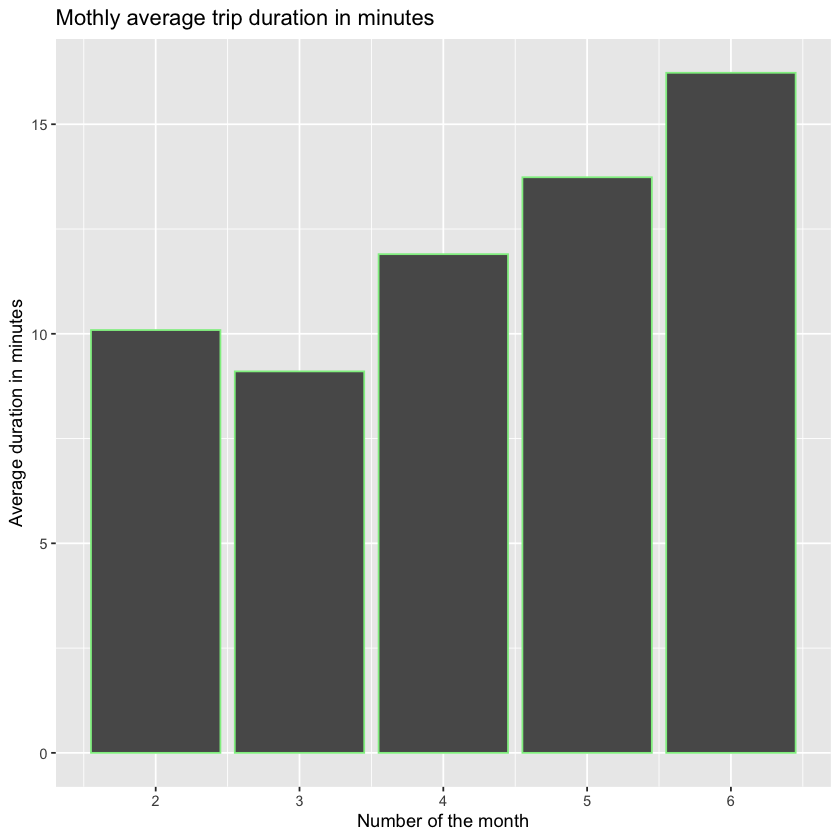

In [8]:
# Mothly average trip duration 

#fI group by the average trip duration by month 

grouped_time <- data %>%
    group_by(month = month(starttime)) %>%
    summarise(avg_time = mean(tripduration))

print(grouped_time)

# Plotting the results 
ggplot(grouped_time, aes (x = month, label = TRUE , y = avg_time/60)) +
    #geom_point(size = 3 )
    geom_bar(stat = "identity",  color = "lightgreen") +
    ggtitle("Mothly average trip duration in minutes") +
    xlab("Number of the month") + 
    ylab("Average duration in minutes")

    

### Plotting the average number of rides per day of the week

week_day,n
<chr>,<int>
2019-02-01 00:04:47.1320,1
2019-02-01 00:10:18.9050,1
2019-02-01 00:23:38.3750,1
2019-02-01 00:49:02.6770,1
2019-02-01 02:46:02.6220,1
2019-02-01 03:29:21.3390,1
2019-02-01 04:44:29.9520,1
2019-02-01 05:36:07.9830,1
2019-02-01 05:39:17.7930,1


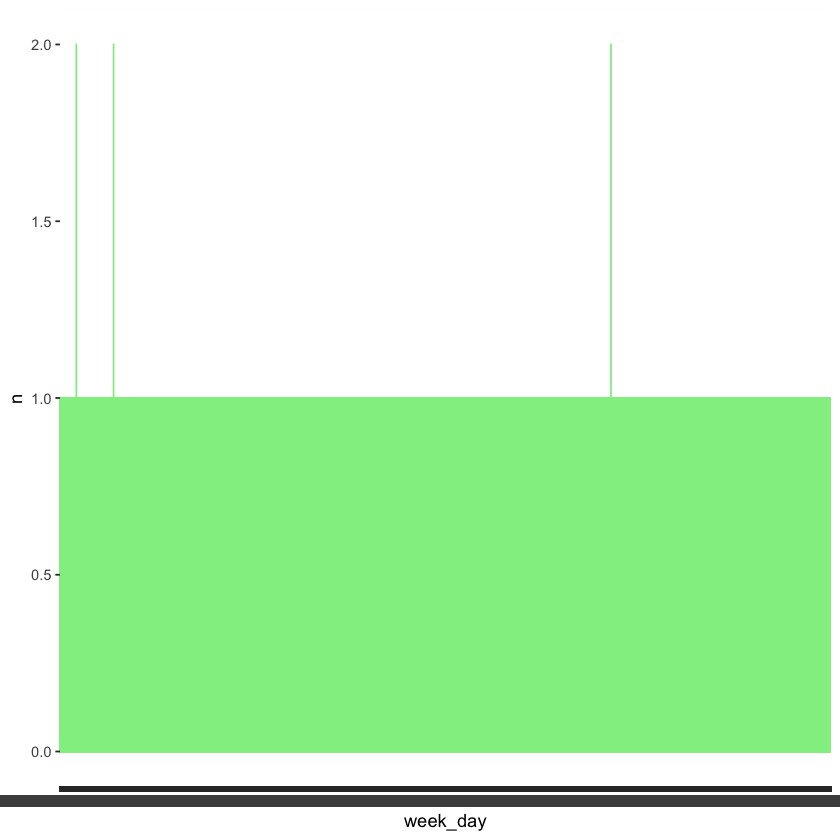

In [9]:

#data$starttime <- as.Date(data$starttime) # setting the column starttime in a date format 


#data$starttime <- wday(data$starttime, label = TRUE, abbr = FALSE, locale = "it_IT") # then converting the date in weekdays + weekends

data_6_1 <- data %>%
    mutate(starttime = hour(as.POSIXct(data$starttime, format = "%Y-%m-%d %H:%M:%S"))) %>%
    mutate(stoptime = wday(as.Date(data$stoptime, format = "%Y-%m-%d %H:%M:%S")))

# Groupping together the number of rides per weekday + weekends
grouped_rides <- data %>%
    group_by(week_day = starttime) %>%
    count()

grouped_rides

#Plotting the results 
ggplot(grouped_rides, aes(x = week_day, y=n)) + 
    geom_bar(stat = "identity",  color = "lightgreen")

### Plotting the hourly distribution on weekdays and on weekends

starttime,n
<int>,<int>
0,462
1,273
2,127
3,97
4,247
5,1183
6,3844
7,9538
8,16322


starttime,n
<int>,<int>
0,533
1,332
2,196
3,132
4,75
5,89
6,240
7,585
8,1223


Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_bar()`)."


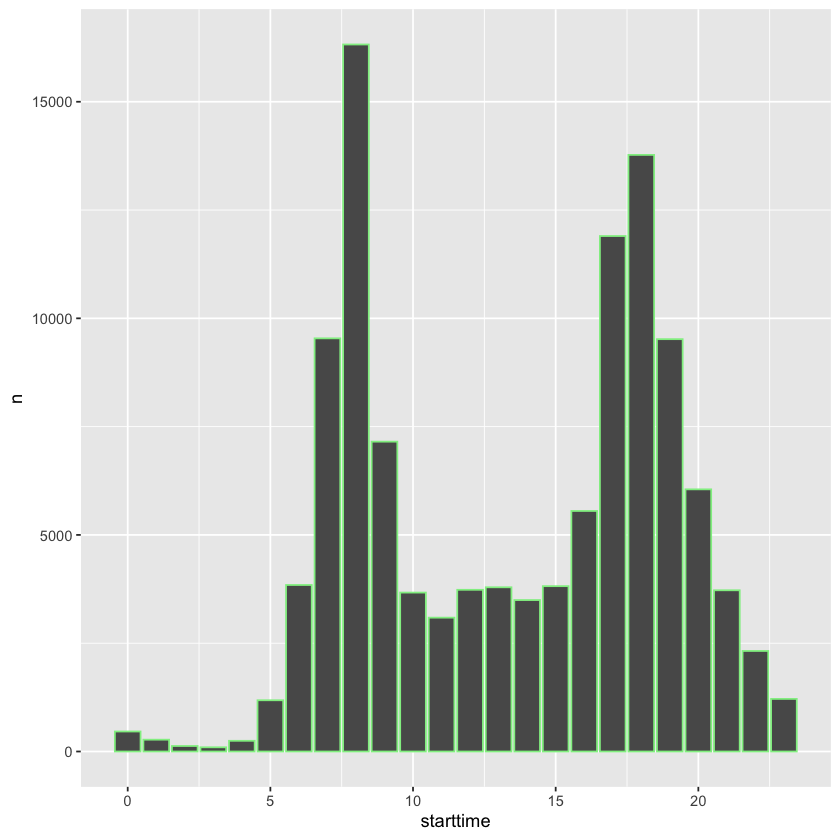

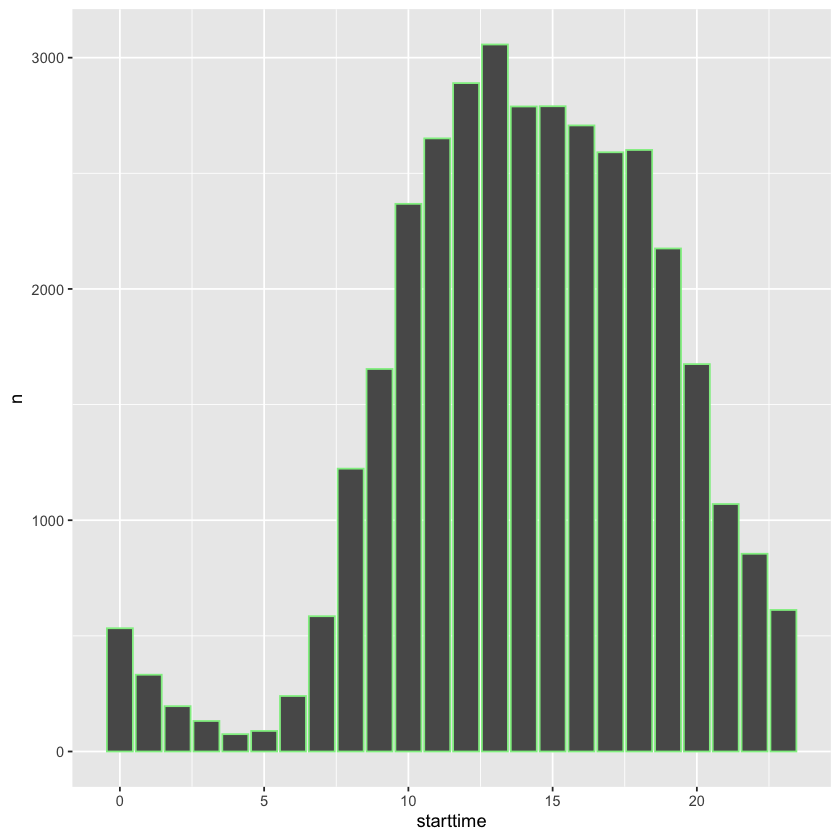

In [10]:
# Convert the "starttime" column in a data format



data_6_2 <- data %>%
    mutate(starttime = hour(as.POSIXct(data$starttime, format = "%Y-%m-%d %H:%M:%S"))) %>%
    mutate(stoptime = wday(as.Date(data$stoptime, format = "%Y-%m-%d %H:%M:%S")))

# Grupped by hour on WEEKDAYS
grouped_by_hour_wd <- data_6_2 %>%
    group_by(starttime) %>%
    filter(stoptime %in% c(2,3,4,5,6)) %>%
    count()

grouped_by_hour_wd

#Plotting the results. It's clear where the commuting hours are
ggplot(grouped_by_hour_wd, aes(x = starttime, y = n)) + 
    geom_bar(stat = "Identity", color = "lightgreen")


# Grupped by hour on WEEKENDS
grouped_by_hour_wd <- data_6_2 %>%
    group_by(starttime) %>%
    filter(stoptime %in% c(7,1)) %>%
    count()

grouped_by_hour_wd

#Plotting the results. 
ggplot(grouped_by_hour_wd, aes(x = starttime, y = n)) + 
    geom_bar(stat = "Identity", color = "lightgreen")

### Plotting again the average hourly distribution on weekdays but separating customer and subscriber users

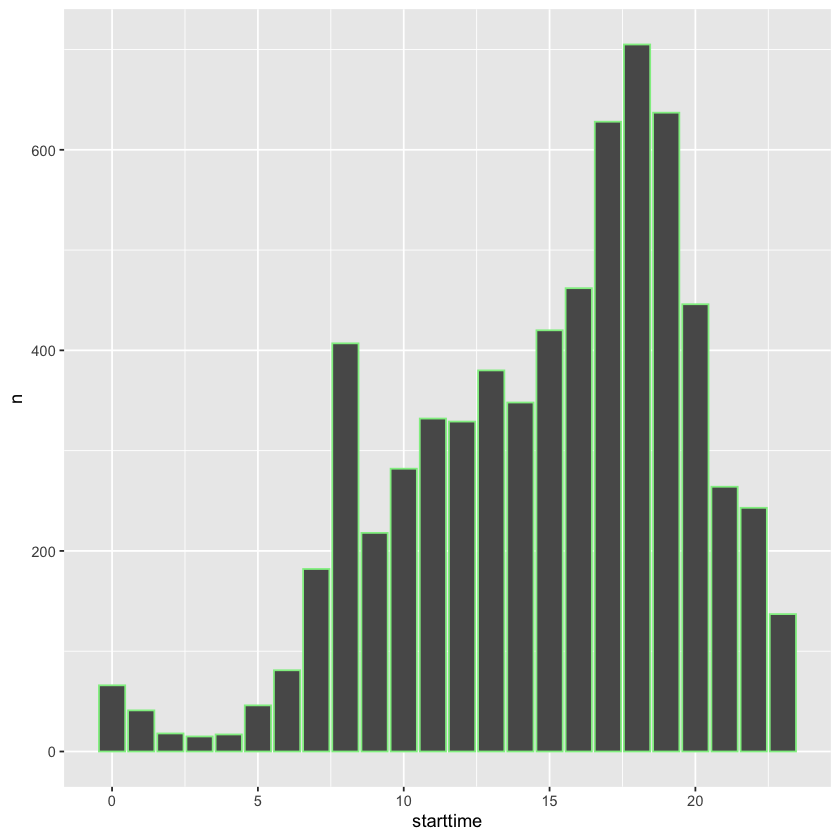

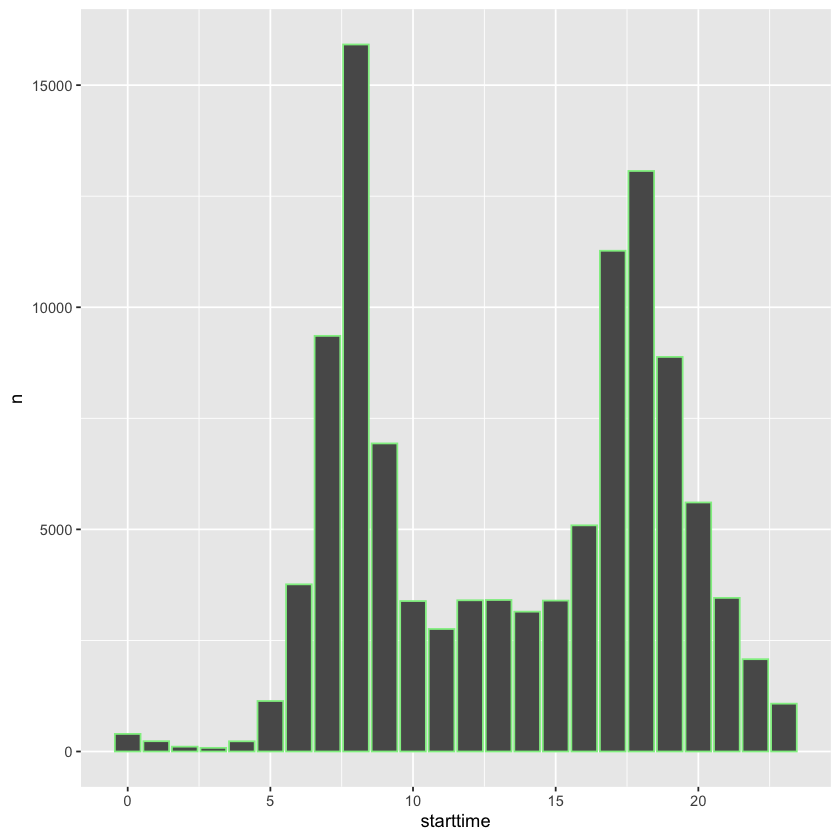

In [11]:

# Groupping the average hourly distribution by weekdays - customers

grouped_by_hour_wd <- data_6_2 %>%
    group_by(starttime) %>%
    filter(stoptime %in% c(2,3,4,5,6)) %>%
    filter(usertype == "Customer") %>%
    count()

#Plotting the results. 
ggplot(grouped_by_hour_wd, aes(x = starttime, y = n)) + 
    geom_bar(stat = "Identity", color = "lightgreen")

# Groupping the average hourly distribution by weekdays - subscriber

grouped_by_hour_wd <- data_6_2 %>%
    group_by(starttime) %>%
    filter(stoptime %in% c(2,3,4,5,6)) %>%
    filter(usertype == "Subscriber") %>%
    count()

#Plotting the results. 
ggplot(grouped_by_hour_wd, aes(x = starttime, y = n)) + 
    geom_bar(stat = "Identity", color = "lightgreen")

In [12]:
head(data)

tripduration,starttime,stoptime,start.station.id,start.station.name,start.station.latitude,start.station.longitude,end.station.id,end.station.name,end.station.latitude,end.station.longitude,bikeid,usertype,birth.year,gender
<int>,<chr>,<chr>,<int>,<chr>,<dbl>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<int>,<chr>,<int>,<int>
142,2019-02-01 15:35:02.0820,2019-02-01 15:37:24.1360,3183,Exchange Place,40.71625,-74.03346,3639,Harborside,40.71925,-74.03423,29677,Subscriber,1963,1
223,2019-02-01 17:00:46.8900,2019-02-01 17:04:30.5500,3183,Exchange Place,40.71625,-74.03346,3681,Grand St,40.71518,-74.03768,26234,Subscriber,1992,2
106,2019-02-01 17:08:01.3260,2019-02-01 17:09:47.4400,3183,Exchange Place,40.71625,-74.03346,3184,Paulus Hook,40.71415,-74.03355,29588,Subscriber,1960,1
370,2019-02-01 17:09:31.2100,2019-02-01 17:15:41.6550,3183,Exchange Place,40.71625,-74.03346,3211,Newark Ave,40.72153,-74.04630,29250,Subscriber,1976,1
315,2019-02-01 17:19:53.2490,2019-02-01 17:25:09.1400,3183,Exchange Place,40.71625,-74.03346,3273,Manila & 1st,40.72165,-74.04288,29586,Subscriber,1980,1
145,2019-02-01 17:32:53.2630,2019-02-01 17:35:18.7510,3183,Exchange Place,40.71625,-74.03346,3214,Essex Light Rail,40.71277,-74.03649,26153,Subscriber,1984,1


### Using the latitude and longitude information, evaluate the average speed (in km/h) of a user, discarding the trip lasting longer than 1 hour

In [ ]:
# Creating a new tabble, converting the units of latitude and longitude (assuming short distance so we can make the semplification
# Latitude: 1° of latitude ≈ 111 km 
# and Longitude: 1° of longitude ≈ 111 km·cos(latitude)
# Also adding new columns: 
    # Distance in km -> the module of the difference between the initial location and the final location
    # Delta time in hours


data_7_1 <- data %>% 
  mutate(
    start.latitude.km = start.station.latitude * 111,
    end.latitude.km = end.station.latitude * 111,
    start.longitude.km = start.station.longitude * 111 * cos(start.station.latitude * pi/180),
    end.longitude.km = end.station.longitude * 111 * cos(end.station.latitude * pi/180),
    distance_km = sqrt((start.latitude.km - end.latitude.km)^2 + (start.longitude.km - end.longitude.km)^2),
    delta_t_hour = tripduration / 3600,
    speed_km_h = distance_km / delta_t_hour
  )

# Filter for trips shorter then 1h
trip_less_1h <- data_7_1 %>% filter(delta_t_hour < 1)

# The average speed
avg_speed <- mean(trip_less_1h$speed_km_h, na.rm = TRUE)
print(avg_speed)


[1] 10.39308


Using the haversine function fro geosphere library instead

In [ ]:
library(dplyr)
library(geosphere)


data_haversine <- data %>% 
  mutate(
    distance_km = distHaversine(
      cbind(start.station.longitude, start.station.latitude),
      cbind(end.station.longitude, end.station.latitude)
    ) / 1000,
    delta_t_hour = tripduration / 3600,
    speed_km_h = distance_km / delta_t_hour
  )

trips_less_than_1h <- data_haversine %>% filter(delta_t_hour < 1)

avg_speed <- mean(trips_less_than_1h$speed_km_h, na.rm = TRUE)
print(avg_speed)


[1] 9.240097


### Plotting the average speed as a function of route length for the following group of distances d < 500 m, 500 m < d < 1000 m, 1000 m < d < 2000 m, 2000 m < d < 3000 m, d > 3000 m and discarding trips longer than 1 hour

In [15]:
# Creating a new tabble, converting the units of latitude and longitude (assuming short distance so we can make the semplification
# Latitude: 1° of latitude ≈ 111 km 
# and Longitude: 1° of longitude ≈ 111 km·cos(latitude)
# Also adding new columns: 
    # Distance in km -> the module of the difference between the initial location and the final location
    # Delta time in hours

data_7_1 <- data %>% 
  mutate(
    start.latitude.km = start.station.latitude * 111,
    end.latitude.km = end.station.latitude * 111,
    start.longitude.km = start.station.longitude * 111 * cos(start.station.latitude * pi/180),
    end.longitude.km = end.station.longitude * 111 * cos(end.station.latitude * pi/180),
    distance_km = sqrt((start.latitude.km - end.latitude.km)^2 + (start.longitude.km - end.longitude.km)^2),
    distance_m = distance_km * 1000,
    delta_t_hour = tripduration / 3600,
    speed_km_h = distance_km / delta_t_hour
  )


# d < 500m 
max500 <- data_7_1 %>% filter(distance_m < 500)
avg_speed_500 <- mean(max500$speed_km_h)
#max500
avg_speed_500

# 500 < d < 1000
max1000 <- data_7_1 %>% filter(distance_m > 500 & distance_m < 1000)
avg_speed_1000 <- mean(max1000$speed_km_h)
#max1000
avg_speed_1000

# 1000 < d < 2000
max2000 <- data_7_1 %>% filter(distance_m > 1000 & distance_m < 2000)
avg_speed_2000 <- mean(max2000$speed_km_h)
#max1000
avg_speed_2000

# 2000 < d < 3000
max3000 <- data_7_1 %>% filter(distance_m > 2000 & distance_m < 3000)
avg_speed_3000 <- mean(max3000$speed_km_h)
#max1000
avg_speed_3000

# d > 3000
plus3000 <- data_7_1 %>% filter(distance_m > 3000)
avg_speed_plus3000 <- mean(plus3000$speed_km_h)
#max1000
avg_speed_plus3000








[1] 6.329113

[1] 9.734225

[1] 12.07328

[1] 13.11515

[1] 12.74119

### Finding the most common start station and the least popular end station

In [16]:
# Finding the most common start station 
group_per_popular <- data %>% 
    group_by(start.station.name) %>%
    count() %>%
    arrange(desc(n))

group_per_popular # the most popular start station is: Grove St PATH

# Finding the least common end station 
group_per_popular_end <- data %>% 
    group_by(end.station.name) %>%
    count() %>%
    arrange(n)

group_per_popular_end # the least popular end station is: 1 Ave & E 16 St

start.station.name,n
<chr>,<int>
Grove St PATH,17902
Hamilton Park,8543
Sip Ave,7228
Newport PATH,6534
Harborside,6254
Marin Light Rail,4830
Exchange Place,4487
City Hall,4113
Newport Pkwy,4087


end.station.name,n
<chr>,<int>
1 Ave & E 16 St,1
8 Ave & W 52 St,1
Broadway & W 56 St,1
E 33 St & 5 Ave,1
Norfolk St & Broome St,1
South St & Gouverneur Ln,1
Spruce St & Nassau St,1
W 15 St & 10 Ave,1
W 15 St & 6 Ave,1


### Finding the three most common routes (start and end station) and the three least popular ones

In [17]:
# Finding the most common routes 
group_per_popular <- data %>% 
    group_by(start.station.name, end.station.name) %>%
    count() %>%
    arrange(desc(n))

group_per_popular 
# The three most common routes are: 
# Hamilton Park ---> Grove St PATH  with 3037 rides , 
# Grove St PATH ---> Hamilton Park	with 2318 rides , 
# Brunswick & 6th ---> Grove St PATH with 1916 rides 

# Finding the least common routes 
group_per_least_popular <- data %>% 
    group_by(start.station.name, end.station.name) %>%
    count() %>%
    arrange(n)

group_per_least_popular
# The three least popular routes are: 
# 5 Corners Library ---> Dixon Mills with 1 ride
# 5 Corners Library ---> Grand St with 1 ride
# Astor Place ---> Brunswick & 6th with 1 ride

start.station.name,end.station.name,n
<chr>,<chr>,<int>
Hamilton Park,Grove St PATH,3037
Grove St PATH,Hamilton Park,2318
Brunswick & 6th,Grove St PATH,1916
Jersey & 6th St,Grove St PATH,1769
Brunswick St,Grove St PATH,1713
Grove St PATH,Brunswick & 6th,1490
Marin Light Rail,Grove St PATH,1438
Dixon Mills,Grove St PATH,1422
Grove St PATH,Marin Light Rail,1414


start.station.name,end.station.name,n
<chr>,<chr>,<int>
5 Corners Library,Dixon Mills,1
5 Corners Library,Grand St,1
Astor Place,Brunswick & 6th,1
Astor Place,Brunswick St,1
Astor Place,Harborside,1
Astor Place,JCBS Depot,1
Astor Place,Leonard Gordon Park,1
Astor Place,Newport PATH,1
Astor Place,Newport Pkwy,1
